In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

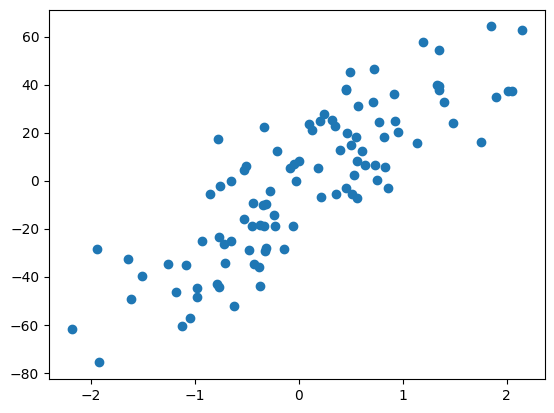

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.linear_model import Ridge

In [5]:
rr=Ridge(alpha=10)
rr.fit(X,y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [7]:
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235726


In [9]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


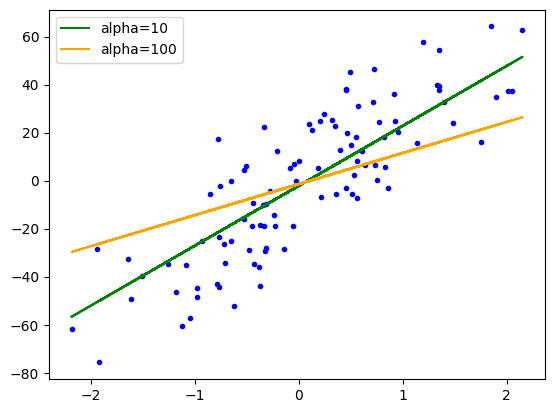

In [10]:
plt.plot(X,y,'b.')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

<h1>Creating MyRidge Class</h1>

In [11]:
class MyRidge:
    def __init__(self,alpha):
        self.alpha=alpha
        self.m=None
        self.b=None

    def fit(self,X_train,y_train):
        num=0
        den=0

        for i in range(X_train.shape[0]):
            num=num+(y_train[i]-y_train.mean())*(X_train[i]-X_train.mean())
            den=den+(X_train[i]-X_train.mean())*(X_train[i]-X_train.mean())

        self.m=num/(den+self.alpha)
        self.b=y_train.mean()-(self.m*X_train.mean())
        print(self.m,self.b)

    def predict(self,X_test):
        pass

In [12]:
reg=MyRidge(10)
reg.fit(X,y)

[24.9546267] [-2.126913]


In [13]:
reg1=MyRidge(100)
reg1.fit(X,y)

[12.93442104] [-1.42484415]


<p>MyRidge Class performs same as the sklearns Ridge</p>

## Ridge Regression Formula for $m$ in 2D

For a simple linear regression model:

$$
y = mx + b
$$

Ridge Regression adds an L2 penalty on the slope $m$:

$$
J(m,b)
=
\sum_{i=1}^{n}(y_i-mx_i-b)^2
+
\lambda m^2
$$

Since the intercept $b$ is not regularized, the optimal intercept is:

$$
b = \bar{y} - m\bar{x}
$$

Substituting this into the Ridge objective gives the Ridge solution for the slope:

$$
\boxed{
m =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sum_{i=1}^{n}(x_i-\bar{x})^2+\lambda
}
}
$$

where:

- $\bar{x}$ = mean of $x$
- $\bar{y}$ = mean of $y$
- $\lambda$ = regularization strength

### Effect of $\lambda$

When $\lambda = 0$, the formula becomes the ordinary Linear Regression slope:

$$
m =
\frac{
\sum (x_i-\bar{x})(y_i-\bar{y})
}{
\sum (x_i-\bar{x})^2
}
$$

As $\lambda$ increases, the denominator increases, so the magnitude of $m$ becomes smaller. This is the **shrinkage effect of Ridge Regression**.